---
tags: [algorithm, machine-learning]
---
# 量子カーネル分類

このチュートリアルでは、Qamomileを使った**量子カーネル法**による二値分類を実演します。パラメータ付き量子回路を使ってカーネル（類似度）行列を計算し、それを古典的なサポートベクターマシン（SVM）に渡します。

以下の手順で進めます:

1. 線形分離できないデータセット(`make_circles`)を準備する。
2. `@qkernel`で**特徴マップ**回路 $U(x)$ を構築する。
3. **オーバーラップカーネル** $k(x, x') = |\langle 0^n | U(x')^\dagger U(x) | 0^n \rangle|^2$ を構成する。
4. グラム行列を計算し、`kernel="precomputed"`でSVMを学習する。
5. 古典的な線形カーネルとRBFカーネルと比較する。

## 背景: 量子カーネル法

量子カーネルは、2つのデータ点の量子特徴状態のオーバーラップを測定することで類似度を推定します:

$$
k(x, x') = |\langle 0^n | U(x')^\dagger \, U(x) | 0^n \rangle|^2
$$

$|0^n\rangle$に$U(x')^\dagger U(x)$を適用し、全ゼロビット列が得られる確率を測定することでこのオーバーラップを推定します。得られたカーネル行列はSVMなどの任意のカーネルベース分類器に渡すことができます。

In [1]:
# !pip install qamomile scikit-learn

## ハイパーパラメータ

In [2]:
import math

RANDOM_STATE = 7
N_SAMPLES = 40
TEST_SIZE = 0.25

LAYERS = 2       # 特徴マップの繰り返し回数（トランスパイル時にバインド）
SHOTS = 1024
C_SVC = 1.0

## データセット

scikit-learnの `make_circles` を使い、同心円状の2クラスデータを生成します。線形分類器が失敗する典型的な例です。

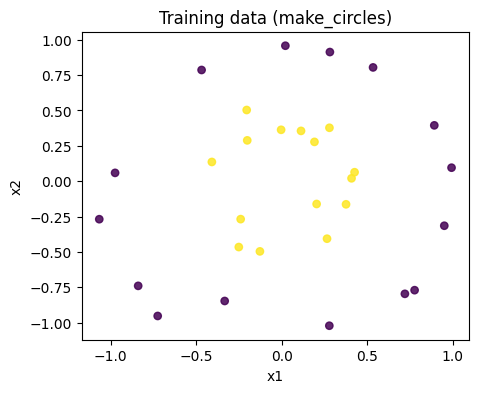

In [3]:
import warnings

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore", message="FigureCanvasAgg is non-interactive")

X_raw, y = make_circles(
    n_samples=N_SAMPLES,
    noise=0.08,
    factor=0.40,
    random_state=RANDOM_STATE,
)

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

plt.figure(figsize=(5, 4))
plt.scatter(
    X_train_raw[:, 0], X_train_raw[:, 1],
    c=y_train, s=28, alpha=0.85,
)
plt.title("Training data (make_circles)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

## 古典的な前処理（特徴リフティング）

量子回路にデータをエンコードする前に、古典的な**特徴リフティング**を適用して元の2次元入力をより高次元の空間に写像します。生の特徴の非線形な組み合わせを追加することで、量子特徴マップがより豊かな構造を活用できるようにします。

2段階のパイプラインは以下の通りです:

1. 生の2次元座標を $[0, \pi]$ にスケーリング。
2. 非線形特徴 $(x_0 - x_1)^2$ と $(x_0 + x_1)^2$ を構築し、それらも $[0, \pi]$ にスケーリング。

これによりサンプルごとに4次元の特徴ベクトルが得られます:
$f(x) = [x_0, x_1, (x_0 - x_1)^2, (x_0 + x_1)^2]$。

したがって量子カーネルは前処理後の特徴上で定義されます:

$$
k(x, x') = |\langle 0^n | U(f(x'))^\dagger \, U(f(x)) | 0^n \rangle|^2
$$

In [4]:
from sklearn.preprocessing import MinMaxScaler

angle_scaler = MinMaxScaler(feature_range=(0.0, math.pi), clip=True)
pair_scaler = MinMaxScaler(feature_range=(0.0, math.pi), clip=True)

X_train_ang = angle_scaler.fit_transform(X_train_raw)
X_test_ang = angle_scaler.transform(X_test_raw)


def lift_features(X_ang: np.ndarray) -> np.ndarray:
    x0 = X_ang[:, 0]
    x1 = X_ang[:, 1]
    xdiff = (x0 - x1) ** 2
    xsum = (x0 + x1) ** 2
    return np.column_stack([x0, x1, xdiff, xsum])


F_train = lift_features(X_train_ang)
F_test = lift_features(X_test_ang)

# 非線形ペア特徴のみスケーリング
F_train[:, 2:4] = pair_scaler.fit_transform(F_train[:, 2:4])
F_test[:, 2:4] = pair_scaler.transform(F_test[:, 2:4])

## 特徴マップ回路

特徴ブロック $U(x)$ は、単一量子ビット回転とエンタングリングゲートでデータをエンコードします。また、ゲート順序を逆にし全角度を符号反転することで正確な逆変換 $U(x)^\dagger$ も実装します。

In [5]:
import qamomile.circuit as qmc


@qmc.qkernel
def feature_block(
    q0: qmc.Qubit,
    q1: qmc.Qubit,
    x0: qmc.Float,
    x1: qmc.Float,
    xdiff: qmc.Float,
    xsum: qmc.Float,
) -> tuple[qmc.Qubit, qmc.Qubit]:
    # 基底変換
    q0 = qmc.h(q0)
    q1 = qmc.h(q1)

    # データエンコーディング
    q0 = qmc.rz(q0, x0)
    q1 = qmc.rz(q1, x1)
    q0 = qmc.ry(q0, x0)
    q1 = qmc.ry(q1, x1)

    # エンタングリング/データ依存位相
    q0, q1 = qmc.cz(q0, q1)
    q0, q1 = qmc.rzz(q0, q1, xdiff)

    # 追加の非線形位相
    q0 = qmc.rz(q0, xsum)
    q1 = qmc.rz(q1, xsum)

    return q0, q1


@qmc.qkernel
def feature_block_dagger(
    q0: qmc.Qubit,
    q1: qmc.Qubit,
    x0: qmc.Float,
    x1: qmc.Float,
    xdiff: qmc.Float,
    xsum: qmc.Float,
) -> tuple[qmc.Qubit, qmc.Qubit]:
    # 逆順、角度を符号反転 (Float に単項マイナスがないため 0.0 - x を使用)
    q1 = qmc.rz(q1, 0.0 - xsum)
    q0 = qmc.rz(q0, 0.0 - xsum)

    q0, q1 = qmc.rzz(q0, q1, 0.0 - xdiff)
    q0, q1 = qmc.cz(q0, q1)

    q1 = qmc.ry(q1, 0.0 - x1)
    q0 = qmc.ry(q0, 0.0 - x0)
    q1 = qmc.rz(q1, 0.0 - x1)
    q0 = qmc.rz(q0, 0.0 - x0)

    q1 = qmc.h(q1)
    q0 = qmc.h(q0)

    return q0, q1

## オーバーラップカーネル回路

完全なカーネル回路は $U(x)$ の後に $U(x')^\dagger$ を適用します。
カーネル値 $k(x, x')$ は $|00\rangle$ を測定する確率です。

表現力を高めるために特徴ブロックを `layers` 回繰り返します。
`layers` は構造パラメータなのでトランスパイル時にバインドします。

In [6]:
@qmc.qkernel
def overlap_kernel(
    layers: qmc.UInt,
    x0: qmc.Float,
    x1: qmc.Float,
    xdiff: qmc.Float,
    xsum: qmc.Float,
    xp0: qmc.Float,
    xp1: qmc.Float,
    xpdiff: qmc.Float,
    xpsum: qmc.Float,
) -> tuple[qmc.Bit, qmc.Bit]:
    q0 = qmc.qubit(name="q0")
    q1 = qmc.qubit(name="q1")

    for _ in qmc.range(layers):
        q0, q1 = feature_block(q0, q1, x0, x1, xdiff, xsum)

    for _ in qmc.range(layers):
        q0, q1 = feature_block_dagger(q0, q1, xp0, xp1, xpdiff, xpsum)

    return qmc.measure(q0), qmc.measure(q1)

## 回路の確認

具体的な値を渡して回路を可視化し、`estimate_resources` でゲート数を確認します。

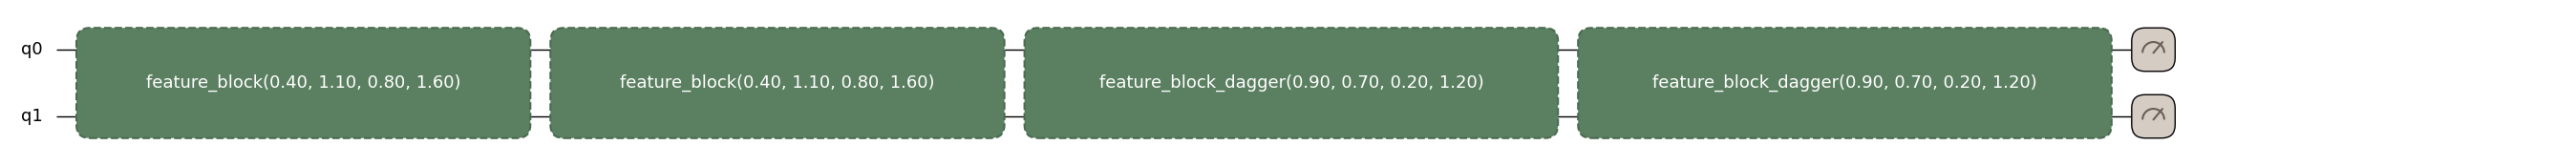

In [7]:
overlap_kernel.draw(
    layers=LAYERS,
    x0=0.4, x1=1.1, xdiff=0.8, xsum=1.6,
    xp0=0.9, xp1=0.7, xpdiff=0.2, xpsum=1.2,
    fold_loops=False,
)

In [8]:
est = overlap_kernel.estimate_resources()
print("=== symbolic resource estimate ===")
print("qubits:", est.qubits)
print("total gates:", est.gates.total)

=== symbolic resource estimate ===
qubits: 2
total gates: 20*layers


## 一度トランスパイル、何度もバインド

構造パラメータ `layers` はトランスパイル時にバインドし、
データ特徴（`x0`, `x1`, ..., `xpsum`）はランタイムパラメータとして残します。これにより、同じコンパイル済み回路をすべてのデータペアに再利用できます。

In [9]:
from qamomile.qiskit import QiskitTranspiler

transpiler = QiskitTranspiler()

exe = transpiler.transpile(
    overlap_kernel,
    bindings={"layers": LAYERS},
    parameters=[
        "x0", "x1", "xdiff", "xsum",
        "xp0", "xp1", "xpdiff", "xpsum",
    ],
)

executor = transpiler.executor()

## カーネル評価ユーティリティ

以下のヘルパー関数を定義します:
- サンプル結果から $|00\rangle$ の確率を取得する。
- 単一のカーネル値 $k(f, f')$ を計算する。
- 対称な訓練カーネル行列を構築する。
- 長方形のテストカーネル行列を構築する。
- ノイズの影響で半正定値性が崩れた場合に、有効な半正定値相関行列に射影する。

In [10]:
def zero_probability(sample_result) -> float:
    total = 0
    zero_zero = 0

    for outcome, count in sample_result.results:
        total += count
        if outcome == (0, 0):
            zero_zero += count

    if total == 0:
        return 0.0
    return zero_zero / total


def kernel_value(f: np.ndarray, fp: np.ndarray, shots: int = SHOTS) -> float:
    result = exe.sample(
        executor,
        shots=shots,
        bindings={
            "x0": float(f[0]),
            "x1": float(f[1]),
            "xdiff": float(f[2]),
            "xsum": float(f[3]),
            "xp0": float(fp[0]),
            "xp1": float(fp[1]),
            "xpdiff": float(fp[2]),
            "xpsum": float(fp[3]),
        },
    ).result()

    return zero_probability(result)


def train_kernel_matrix(F: np.ndarray, shots: int = SHOTS) -> np.ndarray:
    n = len(F)
    K = np.empty((n, n), dtype=float)

    for i in range(n):
        K[i, i] = 1.0
        for j in range(i + 1, n):
            val = kernel_value(F[i], F[j], shots=shots)
            K[i, j] = val
            K[j, i] = val

    return K


def cross_kernel_matrix(
    F_left: np.ndarray, F_right: np.ndarray, shots: int = SHOTS
) -> np.ndarray:
    K = np.empty((len(F_left), len(F_right)), dtype=float)

    for i, f in enumerate(F_left):
        for j, fp in enumerate(F_right):
            K[i, j] = kernel_value(f, fp, shots=shots)

    return K


def project_to_psd_correlation(K: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    K = 0.5 * (K + K.T)

    eigvals, eigvecs = np.linalg.eigh(K)
    eigvals = np.maximum(eigvals, eps)
    K_psd = (eigvecs * eigvals) @ eigvecs.T

    d = np.sqrt(np.maximum(np.diag(K_psd), eps))
    K_psd = K_psd / np.outer(d, d)

    K_psd = 0.5 * (K_psd + K_psd.T)
    np.fill_diagonal(K_psd, 1.0)

    return K_psd

## グラム行列の計算

訓練カーネル行列（対称、$n \times n$）と
テストカーネル行列（長方形、$m \times n$）を計算します。

> **Note:** このステップは $O(n^2)$ 個の量子回路を評価するため計算コストが高くなります。大規模なデータセットの場合はサブサンプリングや近似手法を検討してください。

In [11]:
K_train = train_kernel_matrix(F_train, shots=SHOTS)
K_train = project_to_psd_correlation(K_train)

K_test = cross_kernel_matrix(F_test, F_train, shots=SHOTS)

## 分類器の学習

比較のために3つのSVMを学習します:
- **量子カーネルSVC**: 事前計算した量子カーネル行列を使用。
- **線形SVC**: 生の2次元特徴を使用（円データでは失敗が予想される）。
- **RBF SVC**: 古典的なガウシアンカーネルを使用（強力なベースライン）。

In [12]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

qsvc = SVC(kernel="precomputed", C=C_SVC)
qsvc.fit(K_train, y_train)
y_pred_qk = qsvc.predict(K_test)

linear_svc = SVC(kernel="linear", C=C_SVC)
linear_svc.fit(X_train_raw, y_train)
y_pred_linear = linear_svc.predict(X_test_raw)

rbf_svc = SVC(kernel="rbf", C=C_SVC, gamma="scale")
rbf_svc.fit(X_train_raw, y_train)
y_pred_rbf = rbf_svc.predict(X_test_raw)

print("=== test accuracy ===")
print("Quantum kernel SVC :", accuracy_score(y_test, y_pred_qk))
print("Linear SVC         :", accuracy_score(y_test, y_pred_linear))
print("RBF SVC            :", accuracy_score(y_test, y_pred_rbf))

=== test accuracy ===
Quantum kernel SVC : 1.0
Linear SVC         : 0.5
RBF SVC            : 1.0


## 可視化

4つのパネルをプロットします:
1. 訓練データ。
2. 量子カーネル行列（グラム行列）。
3. 量子カーネル SVC の決定境界。
4. 比較用の古典 RBF SVC の決定境界。

### 決定境界ヘルパー

In [13]:
GRID_SIZE = 15


def preprocess_for_kernel(X_raw_points: np.ndarray) -> np.ndarray:
    X_ang = angle_scaler.transform(X_raw_points)
    F = lift_features(X_ang)
    F[:, 2:4] = pair_scaler.transform(F[:, 2:4])
    return F


def quantum_decision_grid(
    clf: SVC,
    X_train_features: np.ndarray,
    x_min: float,
    x_max: float,
    y_min: float,
    y_max: float,
    grid_size: int = GRID_SIZE,
    shots: int = SHOTS,
):
    xs = np.linspace(x_min, x_max, grid_size)
    ys = np.linspace(y_min, y_max, grid_size)
    xx, yy = np.meshgrid(xs, ys)

    grid_points = np.column_stack([xx.ravel(), yy.ravel()])
    F_grid = preprocess_for_kernel(grid_points)

    K_grid = cross_kernel_matrix(F_grid, X_train_features, shots=shots)

    zz = clf.predict(K_grid).reshape(xx.shape)
    return xx, yy, zz

### 結果のプロット

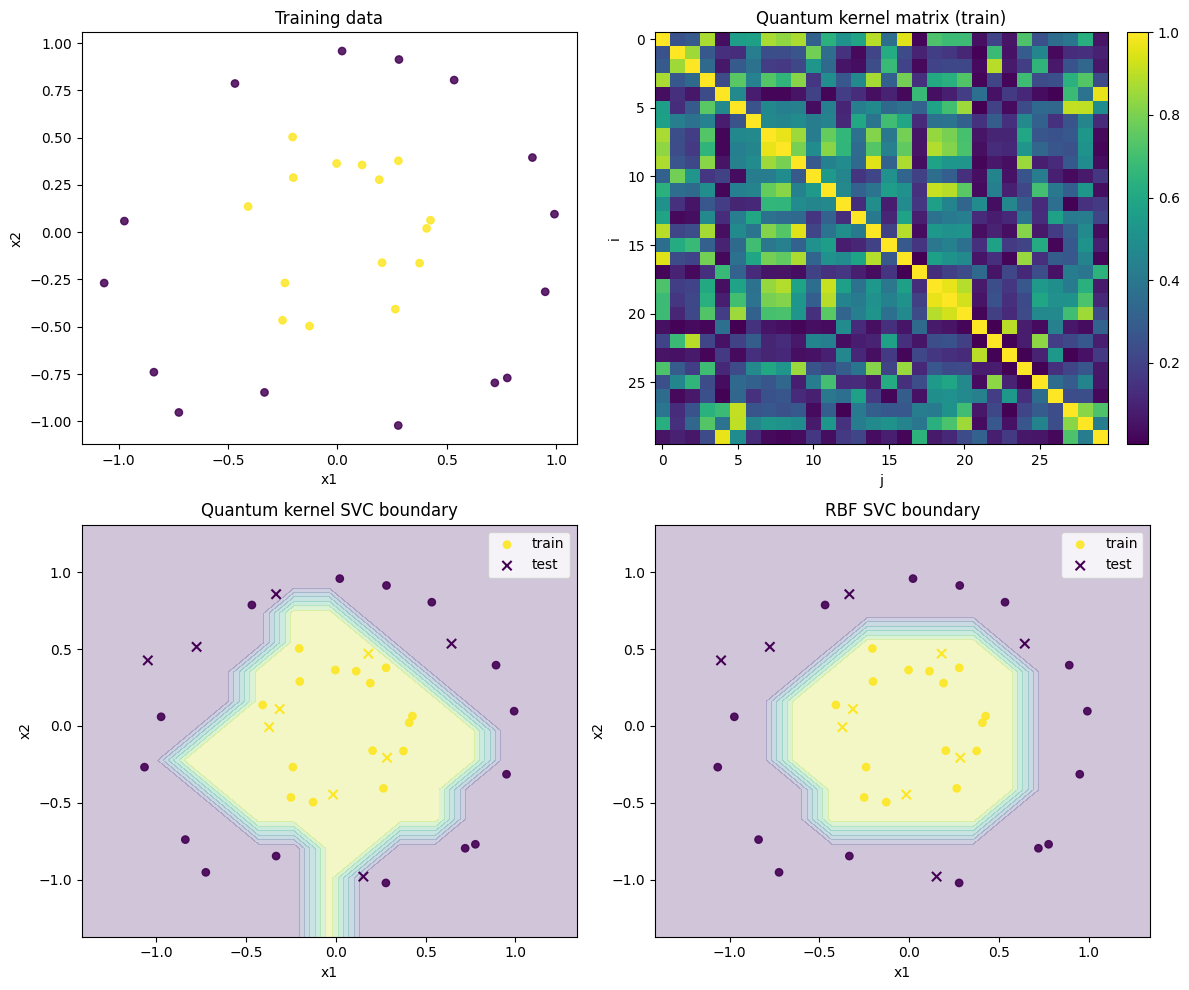

In [14]:
margin = 0.35
x_min = X_raw[:, 0].min() - margin
x_max = X_raw[:, 0].max() + margin
y_min = X_raw[:, 1].min() - margin
y_max = X_raw[:, 1].max() + margin

xx_qk, yy_qk, zz_qk = quantum_decision_grid(
    qsvc, F_train, x_min, x_max, y_min, y_max,
    grid_size=GRID_SIZE, shots=SHOTS,
)

xx_cl, yy_cl = np.meshgrid(
    np.linspace(x_min, x_max, GRID_SIZE),
    np.linspace(y_min, y_max, GRID_SIZE),
)
grid_raw = np.column_stack([xx_cl.ravel(), yy_cl.ravel()])
zz_lin = linear_svc.predict(grid_raw).reshape(xx_cl.shape)
zz_rbf = rbf_svc.predict(grid_raw).reshape(xx_cl.shape)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# (a) 訓練データ
ax = axes[0, 0]
ax.scatter(X_train_raw[:, 0], X_train_raw[:, 1], c=y_train, s=28, alpha=0.85)
ax.set_title("Training data")
ax.set_xlabel("x1")
ax.set_ylabel("x2")

# (b) 訓練カーネル行列
ax = axes[0, 1]
im = ax.imshow(K_train, aspect="auto")
ax.set_title("Quantum kernel matrix (train)")
ax.set_xlabel("j")
ax.set_ylabel("i")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# (c) 量子カーネル決定境界
ax = axes[1, 0]
ax.contourf(xx_qk, yy_qk, zz_qk, alpha=0.25)
ax.scatter(
    X_train_raw[:, 0], X_train_raw[:, 1],
    c=y_train, s=28, alpha=0.9, label="train",
)
ax.scatter(
    X_test_raw[:, 0], X_test_raw[:, 1],
    c=y_test, s=45, marker="x", label="test",
)
ax.set_title("Quantum kernel SVC boundary")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.legend()

# (d) RBF ベースライン
ax = axes[1, 1]
ax.contourf(xx_cl, yy_cl, zz_rbf, alpha=0.25)
ax.scatter(
    X_train_raw[:, 0], X_train_raw[:, 1],
    c=y_train, s=28, alpha=0.9, label="train",
)
ax.scatter(
    X_test_raw[:, 0], X_test_raw[:, 1],
    c=y_test, s=45, marker="x", label="test",
)
ax.set_title("RBF SVC boundary")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.legend()

plt.tight_layout()
plt.show()

## 結果の説明

上の可視化では、量子カーネル分類器が `make_circles` の非線形なクラス構造をどの程度捉えられているかを確認できます。

左上の訓練データを見ると、2つのクラスは直線では分離しにくく、内側の円と外側の円に近い構造を持っています。
実際に、今回の実行では線形SVCのテスト精度は 0.5 であり、ほぼランダム分類に近い結果になっています。
これは、生の2次元座標に対する線形な決定境界では、同心円状のクラス構造を表現できないためです。

右上の量子カーネル行列は、訓練データ同士の類似度

$$
k(x, x') =
\left|
\langle 0^n |
U(f(x'))^\dagger U(f(x))
|0^n\rangle
\right|^2
$$

を並べたグラム行列です。
対角成分は各データ点と自分自身の類似度なので 1 になります。
非対角成分は、異なるデータ点同士が量子特徴空間でどの程度近いかを表しています。
今回の行列はクラス順に並び替えていないため、明確なブロック構造として読むことはできません。
しかし、この行列がSVMに渡されることで、元の2次元空間では線形に分離しにくいデータを、カーネル空間上で分類できるようになります。

左下の量子カーネルSVCの決定境界を見ると、入力空間では非線形な境界が形成されています。
今回の実行では、量子カーネルSVCのテスト精度は 1.0 でした。
したがって、この小規模な `make_circles` データセットに対しては、今回設計した量子特徴マップが有効な類似度を与えていると解釈できます。

右下のRBF SVCも、同じく非線形な決定境界を形成しています。
今回の実行では、RBF SVCのテスト精度も 1.0 でした。
したがって、このデータセットでは量子カーネルSVCとRBF SVCはいずれもテストデータをすべて正しく分類できています。
一方で、RBF SVCの決定境界は比較的滑らかであるのに対し、量子カーネルSVCの境界はやや粗く見えます。
これは、可視化用の格子数 `GRID_SIZE = 15` が小さいことや、カーネル値を `SHOTS = 1024` のサンプリングで推定していることの影響を受けている可能性があります。

以上より、今回の実験では

- 線形SVC: 0.5
- 量子カーネルSVC: 1.0
- RBF SVC: 1.0

となり、量子カーネルSVCは線形SVCよりも明確に良い結果を示し、RBF SVCと同等のテスト精度を達成しました。

ただし、この結果だけから量子優位性を主張することはできません。
今回のデータセットは小規模な可視化用データであり、古典的な特徴リフティングも使用しています。
そのため、ここで示せる結論は
「Qamomileを用いて量子カーネル行列を構成し、それをSVMに渡して非線形二値分類を行える」
という実装上・手法上の確認です。
量子カーネルが古典カーネルより本質的に有利かどうかを議論するには、
より大きなデータセット、複数の乱数シード、ショット数依存性、層数依存性、古典カーネルとの詳細な比較が必要です。

また、今回の量子カーネル評価では、各データ点ペアに対して量子回路を実行してカーネル値を推定します。
そのため、訓練データ数を $n$ とすると、訓練カーネル行列の計算には概ね $O(n^2)$ 個のカーネル評価が必要になります。
今回のような小規模データでは問題ありませんが、データ数を増やす場合には計算コストが急速に増える点に注意が必要です。